In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import boto3
import os
from datetime import datetime, timedelta
from tqdm import tqdm

try:
    import seaborn as sns
except:
    ! pip install seaborn
    import seaborn as sns

np.random.seed(42)

## Helper Classes

In [2]:
class DataCollectionManager:
    """Generate realistic synthetic employee attrition data with seasonality and trends."""
    
    def __init__(self, str_bucket, str_task, str_dirname_output):
        self.str_bucket = str_bucket
        self.str_task = str_task
        self.str_dirname_output = str_dirname_output
        self.s3_client = boto3.client('s3')
        self.list_departments = ['Engineering', 'Sales', 'Marketing', 'HR', 'Finance', 'Operations']
        self.dict_base_attrition = {
            'Engineering': 0.08,
            'Sales': 0.15,
            'Marketing': 0.12,
            'HR': 0.10,
            'Finance': 0.09,
            'Operations': 0.11
        }
        self.dict_base_headcount = {
            'Engineering': 1500,
            'Sales': 1200,
            'Marketing': 600,
            'HR': 300,
            'Finance': 250,
            'Operations': 650
        }
    
    def generate_data(self, int_months=72):
        """Generate 6 years of synthetic HR data."""
        list_records = []
        dt_start = datetime(2020, 1, 1)
        
        # Create time index
        list_dates = [dt_start + timedelta(days=30*i) for i in range(int_months)]
        
        for int_month_idx, dt_date in enumerate(tqdm(list_dates, desc='Generating data')):
            int_month = dt_date.month
            int_year = dt_date.year
            
            for str_dept in self.list_departments:
                # Base headcount with growth trend
                flt_growth_factor = 1.0 + (0.02 * int_month_idx / int_months)
                int_base_hc = int(self.dict_base_headcount[str_dept] * flt_growth_factor)
                
                # Random variation
                int_headcount = int_base_hc + np.random.randint(-50, 51)
                
                # Seasonal attrition pattern
                flt_seasonal = self._get_seasonal_multiplier(int_month)
                flt_base_attrition = self.dict_base_attrition[str_dept]
                flt_attrition = flt_base_attrition * flt_seasonal
                
                # Add noise
                flt_attrition += np.random.normal(0, 0.01)
                flt_attrition = np.clip(flt_attrition, 0.01, 0.30)
                
                # Event months (2 months per year with higher departures)
                if int_month_idx in [10, 25, 42]:  # Restructuring events
                    flt_attrition *= 2.5
                    flt_attrition = np.clip(flt_attrition, 0.01, 0.30)
                
                int_departures = int(int_headcount * flt_attrition)
                
                # New hires: mostly replace departures, some growth
                int_growth = int(int_headcount * 0.005)  # 0.5% monthly growth recruitment
                int_new_hires = int_departures + int_growth + np.random.randint(-10, 11)
                
                # Tenure and satisfaction
                flt_avg_tenure = 3.5 + np.random.normal(0, 0.5)
                flt_avg_satisfaction = 7.0 + np.random.normal(0, 0.8)
                flt_avg_satisfaction = np.clip(flt_avg_satisfaction, 3.0, 10.0)
                
                list_records.append({
                    'date': dt_date,
                    'month': int_month,
                    'year': int_year,
                    'department': str_dept,
                    'headcount': int_headcount,
                    'new_hires': int_new_hires,
                    'departures': int_departures,
                    'attrition_rate': flt_attrition,
                    'avg_tenure_months': flt_avg_tenure * 12,
                    'avg_satisfaction_score': flt_avg_satisfaction
                })
        
        df_data = pd.DataFrame(list_records)
        df_data['date'] = pd.to_datetime(df_data['date'])
        return df_data
    
    def _get_seasonal_multiplier(self, int_month):
        """Return seasonal multiplier based on month of year."""
        dict_seasonal = {
            1: 1.4,   # January: post-bonus departures
            2: 1.3,   # February: continued seasonal
            3: 1.1,
            4: 1.0,
            5: 0.9,
            6: 0.7,   # Summer: lower attrition
            7: 0.7,
            8: 0.8,
            9: 1.2,   # September: back-to-school departures
            10: 1.1,
            11: 0.95,
            12: 0.9   # December: holidays
        }
        return dict_seasonal.get(int_month, 1.0)
    
    def upload_to_s3(self, df_data, str_filename):
        """Upload CSV to S3."""
        str_local_path = f'{self.str_dirname_output}/{str_filename}'
        df_data.to_csv(str_local_path, index=False)
        
        try:
            self.s3_client.upload_file(
                str_local_path,
                self.str_bucket,
                f'00_data_collection/{str_filename}'
            )
            print(f'Uploaded to s3://{self.str_bucket}/00_data_collection/{str_filename}')
        except Exception as e:
            print(f'Error uploading to S3: {e}')
    
    def plot_generated_data(self, df_data):
        """Visualize generated data to verify quality."""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Company-wide attrition over time
        df_company = df_data.groupby('date')['attrition_rate'].mean().reset_index()
        axes[0, 0].plot(df_company['date'], df_company['attrition_rate'], linewidth=2, color='#d62728')
        axes[0, 0].set_title('Company-Wide Attrition Rate Over Time', fontsize=12, fontweight='bold')
        axes[0, 0].set_ylabel('Attrition Rate')
        axes[0, 0].grid(True, alpha=0.3)
        
        # Attrition by department (average)
        df_by_dept = df_data.groupby('department')['attrition_rate'].mean().sort_values(ascending=False)
        axes[0, 1].barh(df_by_dept.index, df_by_dept.values, color='#1f77b4')
        axes[0, 1].set_title('Average Attrition Rate by Department', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Attrition Rate')
        axes[0, 1].grid(True, alpha=0.3, axis='x')
        
        # Headcount trend
        df_hc = df_data.groupby('date')['headcount'].sum().reset_index()
        axes[1, 0].plot(df_hc['date'], df_hc['headcount'], linewidth=2, color='#2ca02c')
        axes[1, 0].set_title('Total Company Headcount Over Time', fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('Headcount')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Seasonal pattern (boxplot by month)
        axes[1, 1].boxplot([df_data[df_data['month'] == int_m]['attrition_rate'].values 
                            for int_m in range(1, 13)],
                           labels=range(1, 13))
        axes[1, 1].set_title('Attrition Rate Distribution by Month', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Month')
        axes[1, 1].set_ylabel('Attrition Rate')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        str_output_path = f'{self.str_dirname_output}/01_generated_data_overview.png'
        plt.savefig(str_output_path, bbox_inches='tight', dpi=150)
        print(f'Saved plot to {str_output_path}')
        plt.show()

## Constants

In [3]:
str_bucket = 'time-series-forecasting-demo'
str_task = 'employee_attrition_forecasting'
str_dirname_output = './output'

## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except FileExistsError:
    pass

print(f'Output directory: {str_dirname_output}')

Output directory: ./output


## Generate Synthetic HR Data

In [5]:
mgr_data = DataCollectionManager(str_bucket, str_task, str_dirname_output)
df_generated = mgr_data.generate_data(int_months=72)

print(f'\nGenerated dataset shape: {df_generated.shape}')
print(f'Date range: {df_generated["date"].min()} to {df_generated["date"].max()}')
print(f'\nFirst few rows:')
print(df_generated.head(10))

Generating data: 100%|██████████| 72/72 [00:00<00:00, 6720.44it/s]


Generated dataset shape: (432, 10)
Date range: 2020-01-01 00:00:00 to 2025-10-31 00:00:00

First few rows:
        date  month  year   department  headcount  new_hires  departures  \
0 2020-01-01      1  2020  Engineering       1501        166         151   
1 2020-01-01      1  2020        Sales       1249        253         250   
2 2020-01-01      1  2020    Marketing        570        107         104   
3 2020-01-01      1  2020           HR        291         45          39   
4 2020-01-01      1  2020      Finance        261         26          33   
5 2020-01-01      1  2020   Operations        672        108         109   
6 2020-01-31      1  2020  Engineering       1539        187         176   
7 2020-01-31      1  2020        Sales       1157        270         261   
8 2020-01-31      1  2020    Marketing        599         90          93   
9 2020-01-31      1  2020           HR        342         51          43   

   attrition_rate  avg_tenure_months  avg_satisfaction_

## Data Summary Statistics

In [6]:
print('\nDataset Summary:')
print(df_generated.describe())

print('\n\nAttrition Rate by Department:')
df_dept_summary = df_generated.groupby('department').agg({
    'attrition_rate': ['mean', 'std', 'min', 'max'],
    'headcount': ['mean', 'min', 'max'],
    'departures': 'sum',
    'new_hires': 'sum'
}).round(4)
print(df_dept_summary)

print('\n\nSeasonal Pattern (Average Attrition by Month):')
df_month_summary = df_generated.groupby('month')['attrition_rate'].agg(['mean', 'std']).round(4)
print(df_month_summary)


Dataset Summary:
                      date       month         year    headcount   new_hires  \
count                  432  432.000000   432.000000   432.000000  432.000000   
mean   2022-12-01 00:00:00    6.347222  2022.430556   755.875000   90.842593   
min    2020-01-01 00:00:00    1.000000  2020.000000   202.000000    7.000000   
25%    2021-06-16 12:00:00    3.000000  2021.000000   310.000000   34.750000   
50%    2022-12-01 00:00:00    6.000000  2022.000000   629.000000   75.000000   
75%    2024-05-16 12:00:00    9.000000  2024.000000  1203.250000  126.000000   
max    2025-10-31 00:00:00   12.000000  2025.000000  1569.000000  437.000000   
std                    NaN    3.420261     1.708391   460.564828   67.997804   

       departures  attrition_rate  avg_tenure_months  avg_satisfaction_score  
count  432.000000      432.000000         432.000000              432.000000  
mean    87.581019        0.114669          42.950739                6.966516  
min     12.000000       

## Visualize Generated Data

/tmp/ipykernel_11812/40134053.py:148: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([df_data[df_data['month'] == int_m]['attrition_rate'].values


Saved plot to ./output/01_generated_data_overview.png


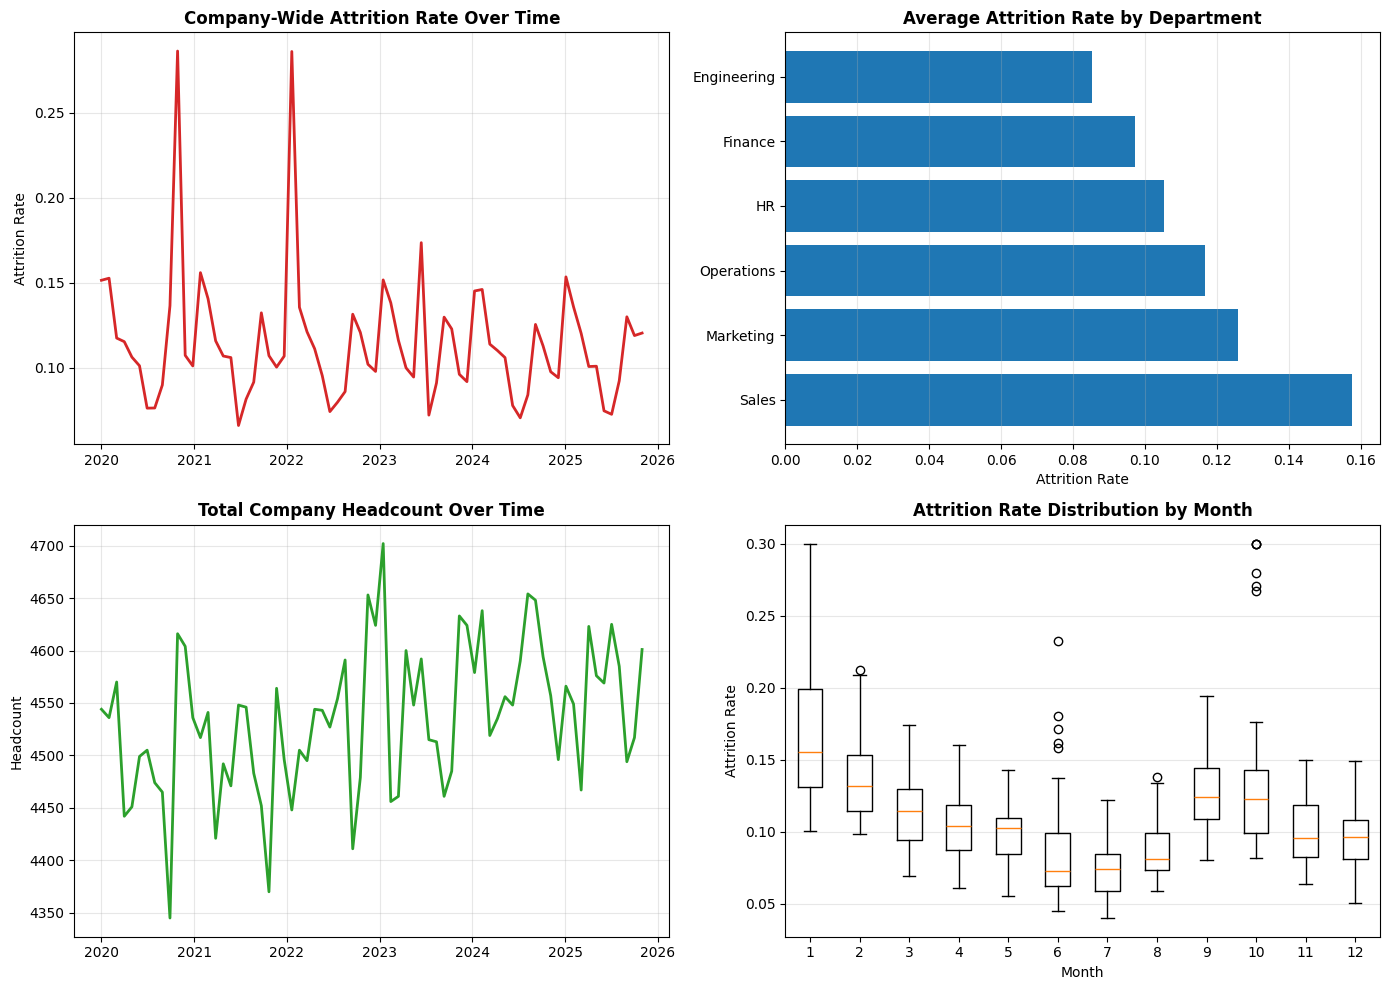

In [7]:
mgr_data.plot_generated_data(df_generated)

## Save to Local and Upload to S3

In [8]:
str_filename = 'employee_attrition_data.csv'

# Save locally
str_local_path = f'{str_dirname_output}/{str_filename}'
df_generated.to_csv(str_local_path, index=False)
print(f'Saved locally to {str_local_path}')

# Upload to S3
mgr_data.upload_to_s3(df_generated, str_filename)

print(f'\nData collection complete!')
print(f'Total records: {len(df_generated):,}')
print(f'Date range: {df_generated["date"].min().date()} to {df_generated["date"].max().date()}')
print(f'Departments: {len(df_generated["department"].unique())}')

Saved locally to ./output/employee_attrition_data.csv
Uploaded to s3://time-series-forecasting-demo/00_data_collection/employee_attrition_data.csv

Data collection complete!
Total records: 432
Date range: 2020-01-01 to 2025-10-31
Departments: 6
